# Fund Performance Attribution & Risk Dashboard
## Part 1: Performance Metrics

Compares **Fund Alpha**, **Peer 1 (Systematic)**, and **Global Equity Index** benchmark.

### How it works
1. **Cell 1** — Install packages (run once)
2. **Cell 2** — Set configuration
3. **Cell 3** — Load data from Yahoo Finance
4. **Cell 4** — Preview the data
5. **Cell 5** — Calculate metrics in Python (for learning)
6. **Cell 6** — Generate the Excel workbook (auto-picks up your data)

---

In [1]:
# ── Cell 1: Install dependencies (run once) ──
!pip install openpyxl pandas numpy yfinance

In [2]:
# ── Cell 2: Configuration ──
import numpy as np
import pandas as pd

RISK_FREE_RATE = 0.045   # Annual risk-free rate — update as needed
START_DATE = "2019-01-01"
END_DATE = "2025-12-31"
BENCHMARK_NAME = "Global Equity Index"

print(f"Period: {START_DATE} to {END_DATE}")
print(f"Risk-free rate: {RISK_FREE_RATE:.1%}")

Period: 2019-01-01 to 2025-12-31
Risk-free rate: 4.5%


In [3]:
# ── Cell 3: Load data from Yahoo Finance ──
import yfinance as yf

tickers = {
    "Fund Alpha": "AHLPX",
    "Peer 1 (Systematic)": "AQMIX",
    "Global Equity Index": "URTH",
}

prices = yf.download(
    list(tickers.values()),
    start=START_DATE,
    end=END_DATE,
    interval="1mo"
)["Close"]

ticker_to_name = {v: k for k, v in tickers.items()}
prices.columns = [ticker_to_name[col] for col in prices.columns]
returns_df = prices.pct_change().dropna()

cols = [c for c in returns_df.columns if c != BENCHMARK_NAME] + [BENCHMARK_NAME]
returns_df = returns_df[cols]

print(f"Downloaded {len(returns_df)} months of data")
print(f"Date range: {returns_df.index[0].strftime('%b %Y')} to {returns_df.index[-1].strftime('%b %Y')}")
print(f"Funds: {list(returns_df.columns)}")

/var/folders/m5/7qgy7ymd1mq6wm0q69bbv0mr0000gn/T/ipykernel_7413/278885377.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(
/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  3 of 3 completed

Downloaded 83 months of data
Date range: Feb 2019 to Dec 2025
Funds: ['Fund Alpha', 'Peer 1 (Systematic)', 'Global Equity Index']


In [4]:
# ── Cell 4: Preview the data ──
print("MONTHLY RETURNS — First 5 rows")
print("=" * 60)
display(returns_df.head().style.format("{:.2%}"))

print("\nSUMMARY STATISTICS")
print("=" * 60)
summary = pd.DataFrame({
    "Mean (monthly)": returns_df.mean(),
    "Std (monthly)": returns_df.std(),
    "Min": returns_df.min(),
    "Max": returns_df.max(),
    "Count": returns_df.count(),
})
display(summary.style.format({
    "Mean (monthly)": "{:.2%}",
    "Std (monthly)": "{:.2%}",
    "Min": "{:.2%}",
    "Max": "{:.2%}",
    "Count": "{:.0f}",
}))

MONTHLY RETURNS — First 5 rows


,Fund Alpha,Peer 1 (Systematic),Global Equity Index
Date,,,
2019-02-01 00:00:00,-0.50%,-0.24%,2.98%
2019-03-01 00:00:00,2.99%,3.42%,1.49%
2019-04-01 00:00:00,2.81%,2.24%,3.72%
2019-05-01 00:00:00,-0.19%,-1.50%,-5.79%
2019-06-01 00:00:00,0.09%,0.82%,4.91%



SUMMARY STATISTICS


,Mean (monthly),Std (monthly),Min,Max,Count
Fund Alpha,0.70%,5.42%,-15.34%,35.91%,83
Peer 1 (Systematic),0.74%,4.05%,-9.74%,13.93%,83
Global Equity Index,1.19%,4.68%,-13.09%,12.86%,83


In [5]:
# ── Cell 5: Calculate metrics in Python (for learning) ──
bench = returns_df[BENCHMARK_NAME]
fund_names = [c for c in returns_df.columns if c != BENCHMARK_NAME]

def calc_metrics(r, b, rf=RISK_FREE_RATE):
    n = len(r)
    ann_ret = (1 + r).prod() ** (12 / n) - 1
    ann_vol = r.std() * np.sqrt(12)
    downside_vol = r[r < 0].std() * np.sqrt(12)
    cum = (1 + r).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    max_dd = dd.min()
    cov_fb = np.cov(r, b)[0, 1]
    var_b = np.var(b, ddof=1)
    beta = cov_fb / var_b if var_b != 0 else 0
    b_ann = (1 + b).prod() ** (12 / len(b)) - 1
    alpha = ann_ret - (rf + beta * (b_ann - rf))
    excess = r.values - b.values
    te = np.std(excess, ddof=1) * np.sqrt(12)
    ir = (np.mean(excess) * 12) / te if te != 0 else 0
    return {
        "Ann. Return": ann_ret, "Ann. Volatility": ann_vol,
        "Sharpe": (ann_ret - rf) / ann_vol if ann_vol != 0 else 0,
        "Sortino": (ann_ret - rf) / downside_vol if downside_vol != 0 else 0,
        "Max Drawdown": max_dd,
        "Calmar": ann_ret / abs(max_dd) if max_dd != 0 else 0,
        "VaR 95%": np.percentile(r, 5),
        "CVaR 95%": r[r <= np.percentile(r, 5)].mean(),
        "Win Rate": (r > 0).mean(),
        "Beta": beta, "Alpha": alpha,
        "Tracking Error": te, "Info Ratio": ir,
    }

results = {name: calc_metrics(returns_df[name], bench) for name in fund_names}
results[BENCHMARK_NAME] = calc_metrics(bench, bench)
metrics_df = pd.DataFrame(results).T

pct_cols = ["Ann. Return", "Ann. Volatility", "Max Drawdown", "VaR 95%",
            "CVaR 95%", "Win Rate", "Alpha", "Tracking Error"]
ratio_cols = ["Sharpe", "Sortino", "Calmar", "Beta", "Info Ratio"]
fmt = {c: "{:.1%}" for c in pct_cols}
fmt.update({c: "{:.2f}" for c in ratio_cols})

print("PERFORMANCE & RISK METRICS")
print("=" * 60)
display(metrics_df.style.format(fmt))

PERFORMANCE & RISK METRICS


,Ann. Return,Ann. Volatility,Sharpe,Sortino,Max Drawdown,Calmar,VaR 95%,CVaR 95%,Win Rate,Beta,Alpha,Tracking Error,Info Ratio
Fund Alpha,7.0%,18.8%,0.13,0.27,-20.0%,0.35,-4.7%,-7.6%,50.6%,0.02,2.3%,24.6%,-0.24
Peer 1 (Systematic),8.2%,14.0%,0.26,0.44,-14.9%,0.55,-5.5%,-7.3%,54.2%,-0.24,5.9%,24.2%,-0.23
Global Equity Index,13.8%,16.2%,0.57,0.86,-24.9%,0.55,-8.0%,-9.7%,67.5%,1.00,0.0%,0.0%,0.00


In [6]:
# ── Cell 6: Generate the Excel workbook ──
# Automatically picks up returns_df from Cell 3 — no manual pasting needed.

%run -i build_dashboard_v2-2.py

print("\n" + "=" * 60)
print("DONE! Open Fund_Performance_Dashboard_v2.xlsx")
print("=" * 60)
print("File saved in your project folder.")
print("All metrics are FORMULAS — change Data sheet and they update.")

Exception: File `'build_dashboard_v2-2.py'` not found.

---

## Next Steps

- **Part 2:** Brinson Attribution — breaks down WHY a fund outperformed
- **Part 3:** Peer Group Comparison — risk/return scatter plots and rankings

# Part 2 - Brinson Attribution

This file generates simulated data in the excel file.  Only need to run once unless the .py file is edited manually (chaging sector weights or factor contributions).

**Simulated Data (Brinson) Sheets 1-3**: modelled on a roughly realistic equity portfolio benchmarked against the S&P500.  The sector weights for the benchmark are loosley based on actual S&P 500 sector weightings (Tech ~28%, Healthcare ~13%, etc.), and the portfolio has deliberate overweights/underweights to make the attribution effects visible. But it's not based on any specific real fund.

**Simulated Data (AHL Factor) Sheets 4-5**: NOT connected to the real AHL data from Part 1. The factor contributions (how much equities, bonds, commodities, and FX each contributed to AHL's return) aren't available from Yahoo Finance. This is realistic numbers based on how managed futures funds typically behave.

In [ ]:
%run -i build_attribution.py

# Part 3 - Peer Group Comparison

In [ ]:
# ── Cell 7: Load expanded peer group data ──
import yfinance as yf

peer_tickers = {
    "Fund Alpha": "AHLPX",
    "Peer 1 (Systematic)": "AQMIX",
    "Peer 2 (Replication)": "DBMF",
    "Peer 3 (Index-Based)": "KMLM",
    "Global Equity Index": "URTH",
}

prices = yf.download(
    list(peer_tickers.values()),
    start=START_DATE,
    end=END_DATE,
    interval="1mo"
)["Close"]

ticker_to_name = {v: k for k, v in peer_tickers.items()}
prices.columns = [ticker_to_name[col] for col in prices.columns]
returns_df_peer = prices.pct_change().dropna()

cols = [c for c in returns_df_peer.columns if c != "Global Equity Index"] + ["Global Equity Index"]
returns_df_peer = returns_df_peer[cols]

print(f"Downloaded {len(returns_df_peer)} months for {len(returns_df_peer.columns)} funds")
print(f"Funds: {list(returns_df_peer.columns)}")

/var/folders/m5/7qgy7ymd1mq6wm0q69bbv0mr0000gn/T/ipykernel_80999/1537599991.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(
[*********************100%***********************]  5 of 5 completed

Downloaded 60 months for 5 funds
Funds: ['Man AHL', 'AQR Managed Futures', 'DBMF (iMGP DBi)', 'KMLM (Mount Lucas)', 'MSCI World']


In [ ]:
# ── Cell 8: Generate peer comparison workbook ──
%run -i build_peer_comparison-2.py

✅ Using REAL peer data from notebook (60 months)
   Funds: ['Man AHL', 'AQR Managed Futures', 'DBMF (iMGP DBi)', 'KMLM (Mount Lucas)', 'MSCI World']
✅ Peer comparison workbook saved: Fund_Peer_Comparison.xlsx
   Sheets: ['Peer Comparison', 'Rankings', 'Risk-Return Plot', 'Calendar Year Returns', 'Rolling Sharpe', 'Cumulative Growth', 'Drawdown Comparison', 'Data']
   Funds compared: 5
   Months: 60 (Jan 2021 to Dec 2025)
   Overall ranking: AQR Managed Futures (1.6), MSCI World (2.1), DBMF (iMGP DBi) (2.9), Man AHL (3.6), KMLM (Mount Lucas) (4.9)


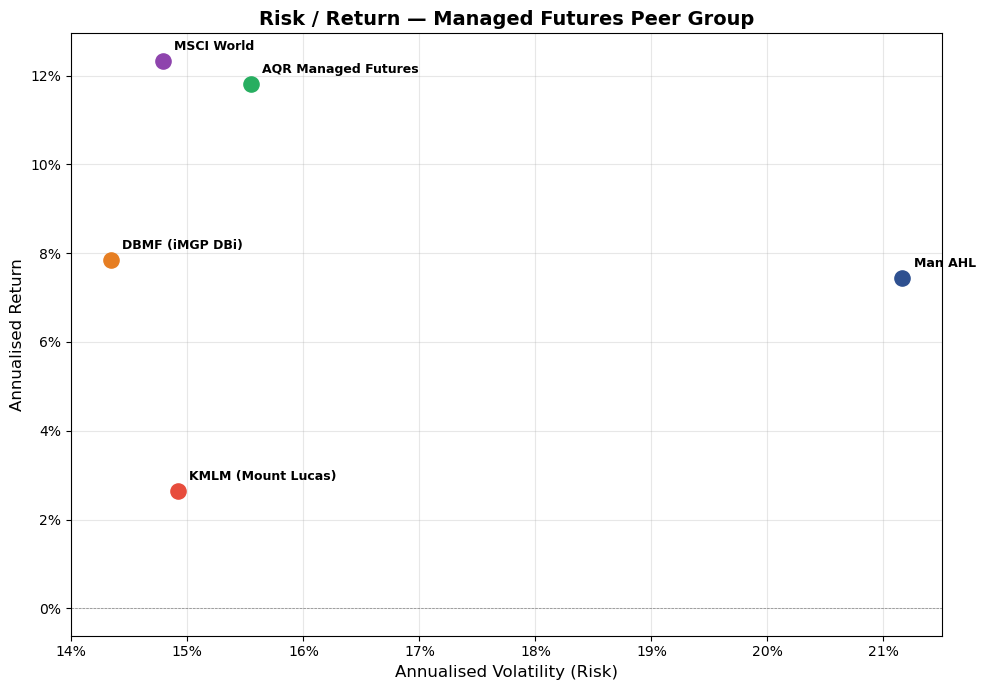

Saved: risk_return_scatter.png


In [ ]:
# ── Cell 9: Risk/Return Scatter Plot (visual) ──
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

bench = "Global Equity Index"
colours = {"Fund Alpha": "#2E5090", "Peer 1 (Systematic)": "#27AE60", 
           "Peer 2 (Replication)": "#E67E22", "Peer 3 (Index-Based)": "#E74C3C", 
           "Global Equity Index": "#8E44AD"}

for fund in returns_df_peer.columns:
    r = returns_df_peer[fund]
    n = len(r)
    ann_ret = (1 + r).prod() ** (12 / n) - 1
    ann_vol = r.std() * np.sqrt(12)
    ax.scatter(ann_vol, ann_ret, s=120, c=colours.get(fund, "grey"), zorder=5)
    ax.annotate(fund, (ann_vol, ann_ret), textcoords="offset points", 
                xytext=(8, 8), fontsize=9, fontweight='bold')

ax.set_xlabel("Annualised Volatility (Risk)", fontsize=12)
ax.set_ylabel("Annualised Return", fontsize=12)
ax.set_title("Risk / Return — Managed Futures Peer Group", fontsize=14, fontweight='bold')
ax.axhline(y=0, color='grey', linewidth=0.5, linestyle='--')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig("risk_return_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: risk_return_scatter.png")

# Part 4 - Risk Report

In [ ]:
# Cell 10 - Build Risk Report
%run -i build_risk_report.py

✅ Using REAL data from notebook (84 months)
✅ Risk report saved: Fund_Risk_Report.xlsx
   Sheets: ['Executive Summary', 'Risk Metrics', 'Exposure Breakdown', 'Drawdown Monitor', 'Stress Testing', 'Limit Monitoring', 'Risk Commentary']
   Report date: December 2025
   Fund: Man AHL
   Metrics: NAV=$1,287, DD=0.0%, Vol=10.9%, Sharpe=-0.08
